In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text
import os

# Configuring visual defaults
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10

# Move to project root 
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.getcwd())

load_dotenv() 

## Database Connection
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine =create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

with engine.connect() as conn:
    result = conn.execute(text("select count(*) from fraud_dw.fact_transactions"))
    count = result.scalar()
    print(f"Connected to database. Fact_transactions has {count:,} rows.")


Working directory: d:\Innomatics\Git_Uploads\Credit-card-risk-analytics
Connected to database. Fact_transactions has 590,540 rows.


In [2]:
## Query 1 --  Fraud rate by amount quintile

query1 = """

with amt_buckets as(
	select 		
			transaction_id,
			is_fraud,
			transaction_amt,
			ntile(5) over (order by transaction_amt) as amt_quintile
	from fraud_dw.fact_transactions
)

select 
		amt_quintile,
		count(*) 						as txn_count,
		round(min(transaction_amt),2) 	as min_amt,
		round(max(transaction_amt),2)	as max_amt,
		count(*) filter(where is_fraud)	as fraud_count,
		round(100 * count(*)
			filter (where is_fraud)/count(*),2)		as fraud_rate_pct
from amt_buckets
group by amt_quintile
order by amt_quintile;
"""

df1 = pd.read_sql(query1,engine)
df1

,amt_quintile,txn_count,min_amt,max_amt,fraud_count,fraud_rate_pct
0,1,118108,0.25,35.95,5296,4.0
1,2,118108,35.95,57.95,3232,2.0
2,3,118108,57.95,100.00,3678,3.0
3,4,118108,100.00,159.95,3223,2.0
4,5,118108,159.95,31937.39,5234,4.0


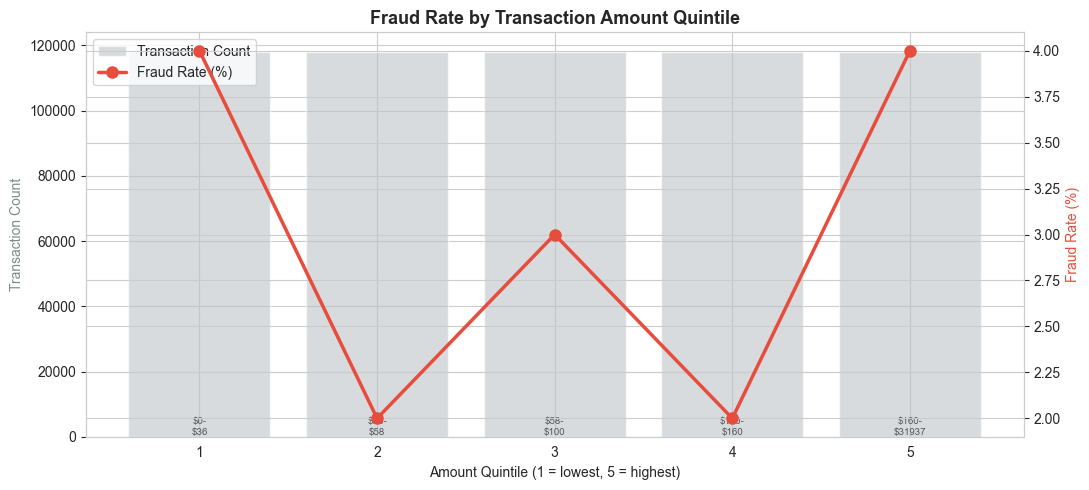

In [4]:
## Q1 plot

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

x = df1['amt_quintile']
ax1.bar(x, df1['txn_count'], color='#bdc3c7', alpha=0.6, label='Transaction Count')
ax1.set_xlabel('Amount Quintile (1 = lowest, 5 = highest)')
ax1.set_ylabel('Transaction Count', color='#7f8c8d')

ax2.plot(x, df1['fraud_rate_pct'], color='#e74c3c', 
         marker='o', linewidth=2.5, markersize=8, label='Fraud Rate (%)')
ax2.set_ylabel('Fraud Rate (%)', color='#e74c3c')

# Label each quintile with its dollar range
for xi, mn, mx in zip(x, df1['min_amt'], df1['max_amt']):
    ax1.text(xi, 0, f'${mn:.0f}-\n${mx:.0f}', ha='center', va='bottom', 
             fontsize=7, color='#555')

ax1.set_title('Fraud Rate by Transaction Amount Quintile',
              fontsize=13, fontweight='bold')

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, loc='upper left')

plt.tight_layout()
plt.savefig('visuals/phase4_q1_amount_quintile.png', bbox_inches='tight')
plt.show()